<a href="https://colab.research.google.com/github/tikadatta2005/CSC60904-Deep-Learning-T3/blob/main/EDA_Nepali_Character_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA - Nepali Character Dataset (NSLv2)

In [1]:
import os

repo_url = "https://github.com/tikadatta2005/CSC60904-Deep-Learning-T3.git"
repo_dir = "CSC60904-Deep-Learning-T3"

if not os.path.exists(repo_dir):
    !git clone {repo_url}

os.chdir(repo_dir)

!pip install -q scikit-learn seaborn matplotlib pandas pillow

print("Repository ready.")

Cloning into 'CSC60904-Deep-Learning-T3'...
remote: Enumerating objects: 317, done.
remote: Counting objects: 100% (317/317), done.
remote: Compressing objects: 100% (238/238), done.
remote: Total 317 (delta 113), reused 260 (delta 61), pack-reused 0 (from 0)
Receiving objects: 100% (317/317), 6.02 MiB | 7.83 MiB/s, done.
Resolving deltas: 100% (113/113), done.
Repository ready.


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path

ZIP_PATH = "/content/drive/MyDrive/CSC60904_Projects/NSLv2.zip"
EXTRACT_PATH = "/content/NSLv2"
FINAL_PATH = "./datasets/final_dataset"

folders = [
    "क","ख","ग","घ","ङ",
    "च","छ","ज","झ","ञ",
    "ट","ठ","ड","ढ","ण",
    "त","थ","द","ध","न",
    "प","फ","ब","भ","म",
    "य","र","ल","व","श",
    "ष","स","ह","क्ष","त्र","ज्ञ"
]

In [4]:
import zipfile
import shutil
import random
import uuid

def check_counts(path):
    expected = {"train": 35100, "val": 10800, "test": 8100}

    for split in expected:
        split_path = Path(path) / split
        if not split_path.exists():
            return False
        count = sum(1 for f in split_path.rglob("*") if f.is_file())
        if count != expected[split]:
            return False

    return True

if os.path.exists(FINAL_PATH) and check_counts(FINAL_PATH):
    print("Dataset already exists, skipping rebuild.")

else:
    if os.path.exists(FINAL_PATH):
        shutil.rmtree(FINAL_PATH)

    print("Extracting dataset...")

    if not os.path.exists(EXTRACT_PATH):
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(EXTRACT_PATH)

    random.seed(41)

    base = Path(FINAL_PATH)

    for folder in folders:
        (base/"train"/folder).mkdir(parents=True, exist_ok=True)
        (base/"val"/folder).mkdir(parents=True, exist_ok=True)
        (base/"test"/folder).mkdir(parents=True, exist_ok=True)

    data_root = Path(EXTRACT_PATH)/"NSLv2"/"data"

    if not (data_root/"Plain Background").exists():
        data_root = Path(EXTRACT_PATH)/"data"
        if not (data_root/"Plain Background").exists():
            possible = list(Path(EXTRACT_PATH).rglob("Plain Background"))
            if possible:
                data_root = possible[0].parent

    for index, name in enumerate(folders):
        plain = data_root/"Plain Background"/str(index)
        random_bg = data_root/"Random Background"/str(index)

        images = []
        if plain.exists():
            images.extend(list(plain.iterdir()))
        if random_bg.exists():
            images.extend(list(random_bg.iterdir()))

        if len(images) == 0:
            continue

        random.shuffle(images)

        train_end = int(len(images)*0.65)
        val_end = int(len(images)*0.20)

        splits = {
            "train": images[:train_end],
            "val": images[train_end:train_end+val_end],
            "test": images[train_end+val_end:]
        }

        for split, file_list in splits.items():
            output = base/split/name
            for image in file_list:
                if image.is_file():
                    shutil.copy2(image, output/f"{uuid.uuid4()}-{uuid.uuid4()}-{name}.png")

    print("Dataset preprocessing complete.")

Extracting dataset...
Dataset preprocessing complete.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import matplotlib.font_manager as fm
import tempfile
import urllib.request

sns.set_theme(style="whitegrid")

In [6]:
font_name = None

for f in fm.fontManager.ttflist:
    if "nirmala ui" in f.name.lower():
        font_name = f.name
        break

if not font_name:
    font_url = "https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansDevanagari/NotoSansDevanagari-Regular.ttf"
    font_path = os.path.join(tempfile.gettempdir(), "NotoSansDevanagari-Regular.ttf")

    if (not os.path.exists(font_path)) or os.path.getsize(font_path) < 10000:
        urllib.request.urlretrieve(font_url, font_path)

    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = [font_name, "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

## 1. Dataset overview - file counts per split and class

In [7]:
records = []

for split in ["train", "val", "test"]:
    split_path = Path(FINAL_PATH) / split
    for class_dir in sorted(split_path.iterdir()):
        if not class_dir.is_dir():
            continue
        for f in class_dir.iterdir():
            if f.is_file():
                records.append({
                    "split": split,
                    "class": class_dir.name,
                    "path": str(f)
                })

df = pd.DataFrame(records)
print(f"Total images indexed: {len(df)}")
df.head()

Total images indexed: 54000


,split,class,path
0,train,क,datasets/final_dataset/train/क/4654caf0-45a8-4...
1,train,क,datasets/final_dataset/train/क/0724b00d-3251-4...
2,train,क,datasets/final_dataset/train/क/e0cd5a16-dbb9-4...
3,train,क,datasets/final_dataset/train/क/308f7b63-fe82-4...
4,train,क,datasets/final_dataset/train/क/b32e9716-1cc3-4...


split
train    35100
val      10800
test      8100
Name: count, dtype: int64


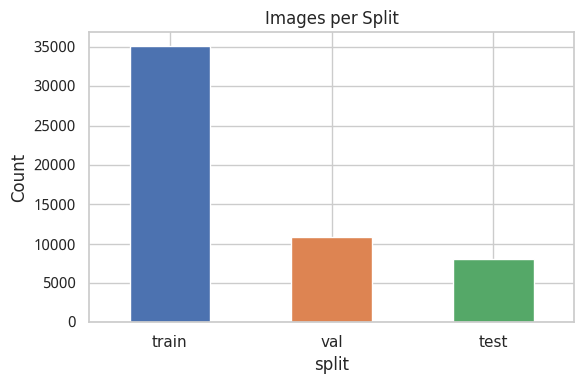

In [8]:
split_counts = df["split"].value_counts().reindex(["train", "val", "test"])
print(split_counts)

split_counts.plot(kind="bar", figsize=(6, 4), color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Images per Split")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

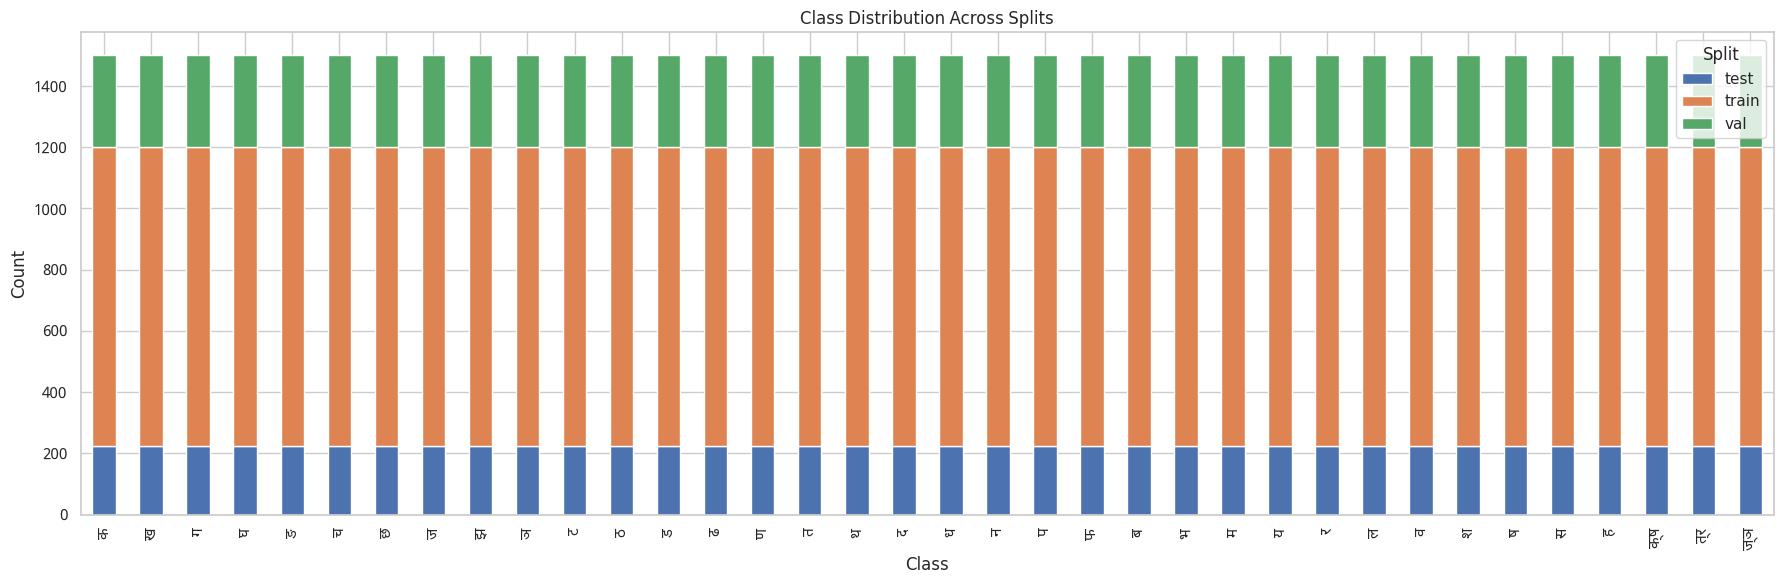

split,test,train,val
class,,,
क,225,975,300
ख,225,975,300
ग,225,975,300
घ,225,975,300
ङ,225,975,300
च,225,975,300
छ,225,975,300
ज,225,975,300
झ,225,975,300


In [9]:
class_split_counts = df.groupby(["class", "split"]).size().unstack(fill_value=0).reindex(folders)

class_split_counts.plot(kind="bar", stacked=True, figsize=(18, 6))
plt.title("Class Distribution Across Splits")
plt.ylabel("Count")
plt.xlabel("Class")
plt.legend(title="Split")
plt.tight_layout()
plt.show()

class_split_counts

In [10]:
total_per_class = class_split_counts.sum(axis=1)

print("Most represented classes:")
print(total_per_class.sort_values(ascending=False).head(5))

print("\nLeast represented classes:")
print(total_per_class.sort_values(ascending=True).head(5))

print(f"\nMax/min ratio: {total_per_class.max() / total_per_class.min():.2f}")

Most represented classes:
class
क    1500
ख    1500
ग    1500
घ    1500
ङ    1500
dtype: int64

Least represented classes:
class
क    1500
ख    1500
ग    1500
घ    1500
ङ    1500
dtype: int64

Max/min ratio: 1.00


## 2. Sample images

Grid of one random sample per class from the training split, to sanity-check labels
and visually compare characters that look similar.

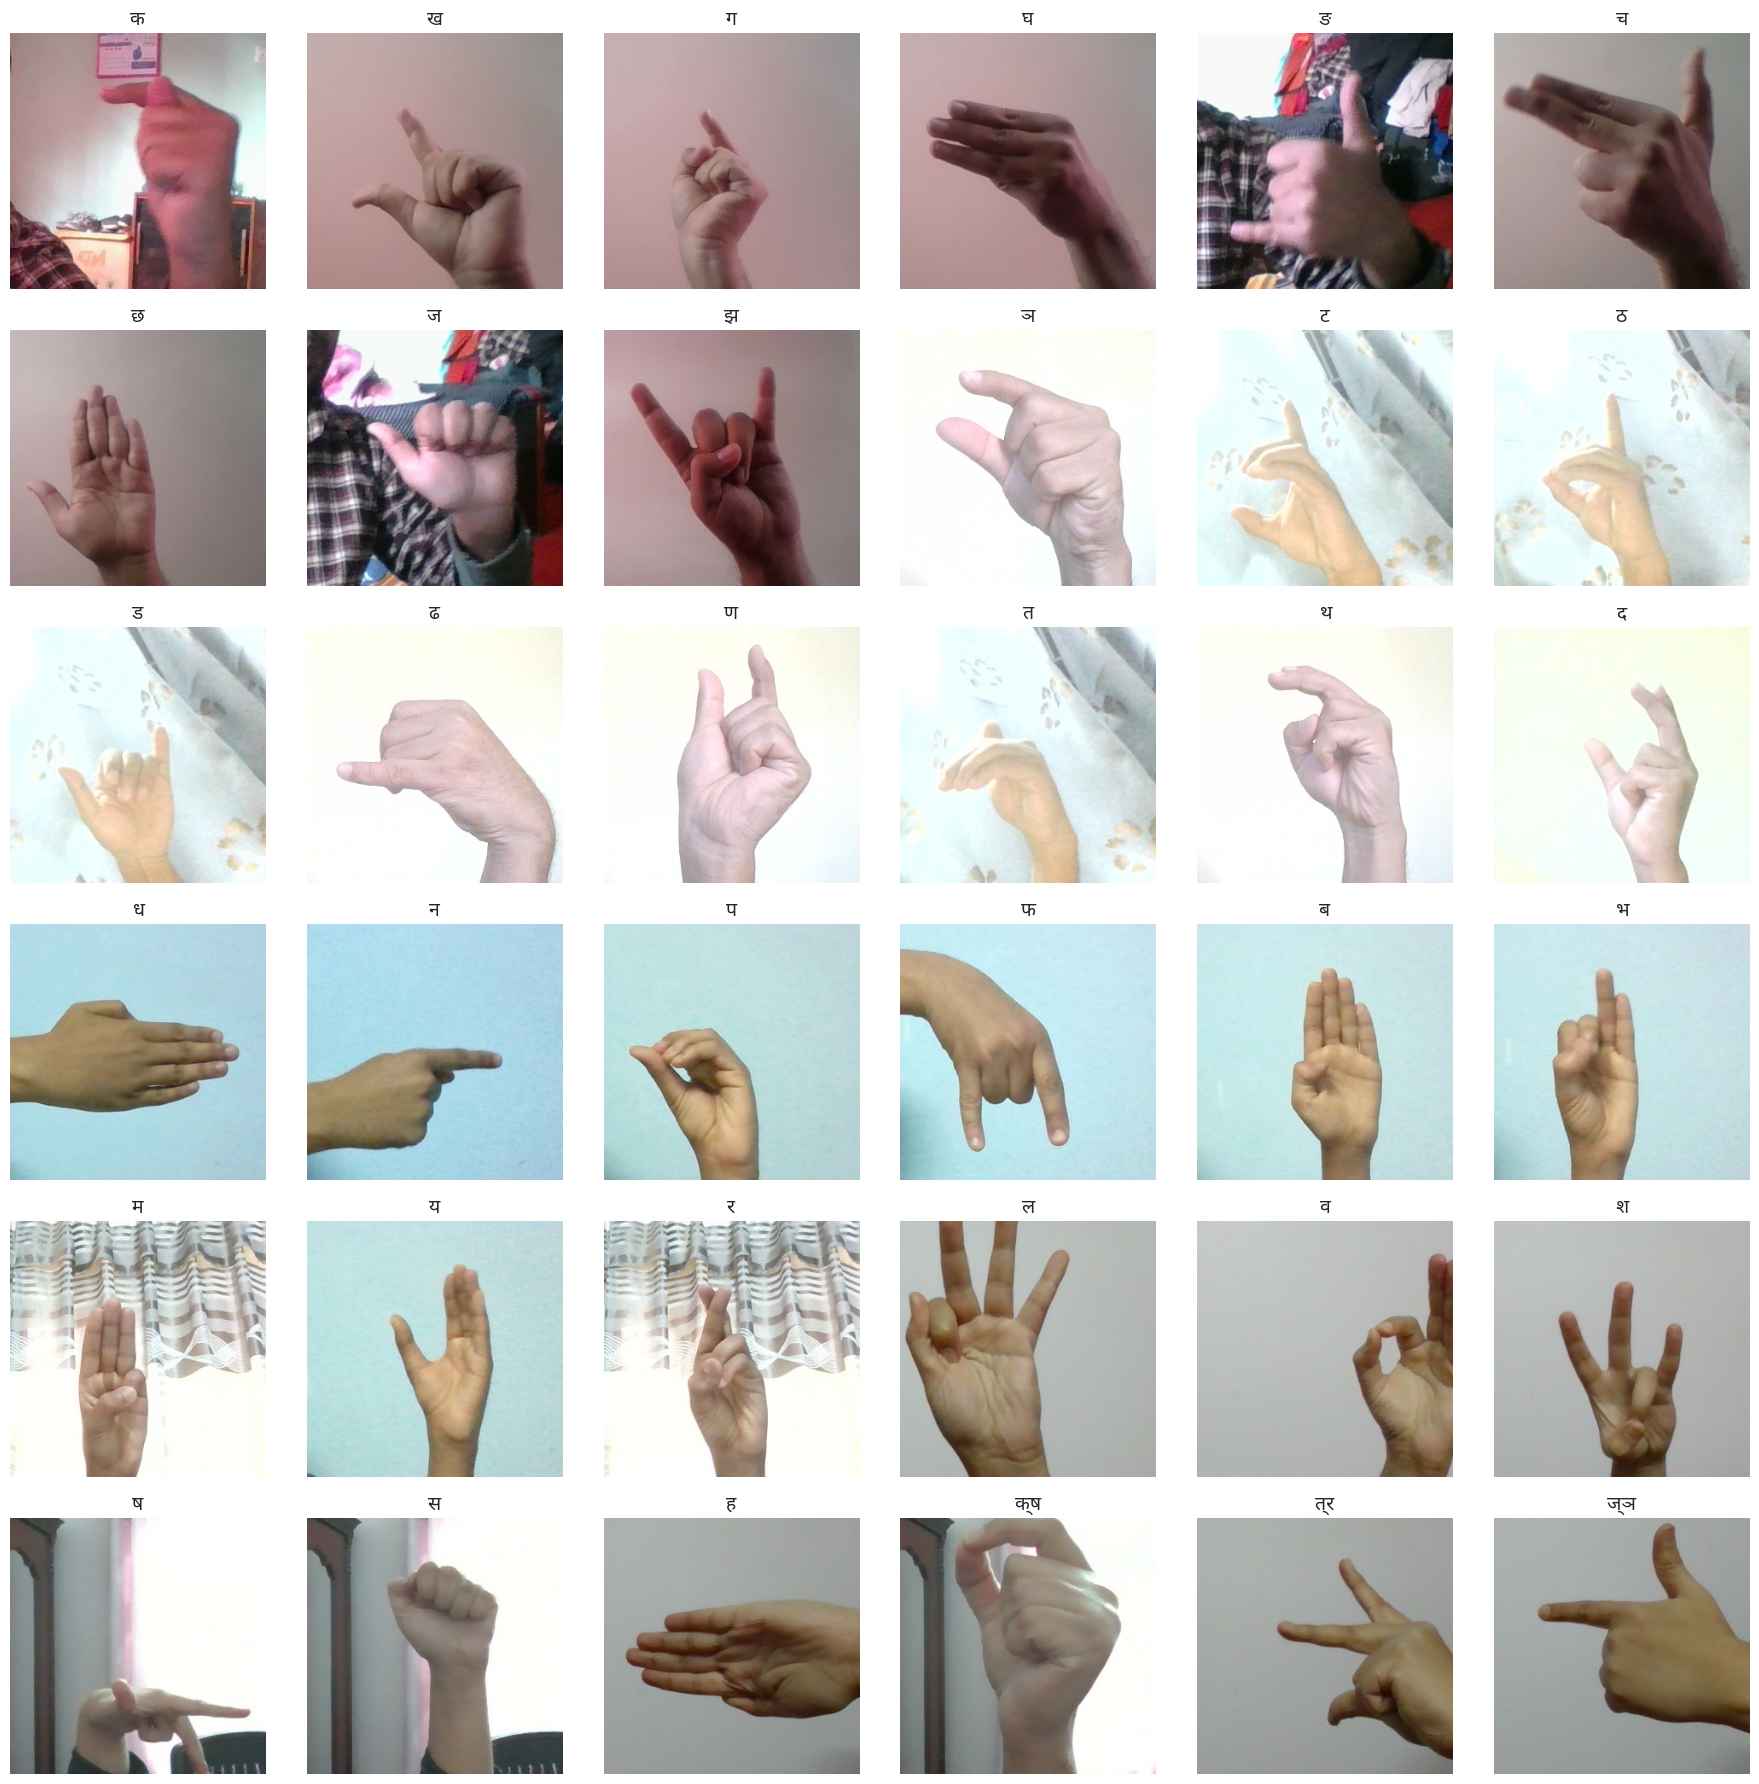

In [11]:
fig, axes = plt.subplots(6, 6, figsize=(18, 18))
axes = axes.flatten()

train_df = df[df["split"] == "train"]

for i, cls in enumerate(folders):
    cls_files = train_df[train_df["class"] == cls]["path"]
    if len(cls_files) == 0:
        axes[i].axis("off")
        continue

    sample_path = cls_files.sample(1, random_state=41).iloc[0]
    img = Image.open(sample_path)

    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=14)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 3. Image size and aspect ratio check

        width  height
count  2000.0  2000.0
mean    300.0   300.0
std       0.0     0.0
min     300.0   300.0
25%     300.0   300.0
50%     300.0   300.0
75%     300.0   300.0
max     300.0   300.0


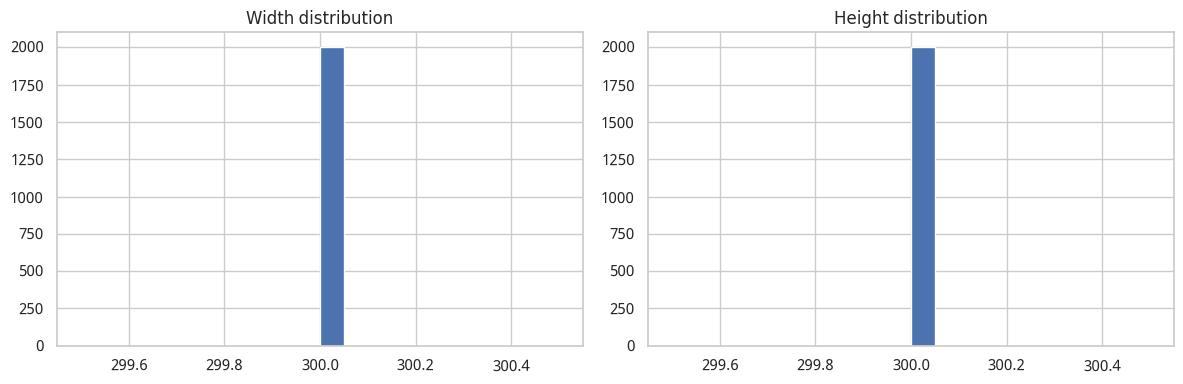


Unique (width, height) pairs in sample: 1


,width,height
14182,300,300


In [12]:
SAMPLE_SIZE = 2000

sample_df = df.sample(min(SAMPLE_SIZE, len(df)), random_state=41)

widths, heights = [], []

for p in sample_df["path"]:
    with Image.open(p) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

sample_df = sample_df.assign(width=widths, height=heights)

print(sample_df[["width", "height"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sample_df["width"].hist(ax=axes[0], bins=20)
axes[0].set_title("Width distribution")
sample_df["height"].hist(ax=axes[1], bins=20)
axes[1].set_title("Height distribution")
plt.tight_layout()
plt.show()

unique_sizes = sample_df[["width", "height"]].drop_duplicates()
print(f"\nUnique (width, height) pairs in sample: {len(unique_sizes)}")
unique_sizes.head(10)

## 4. Brightness / pixel intensity check

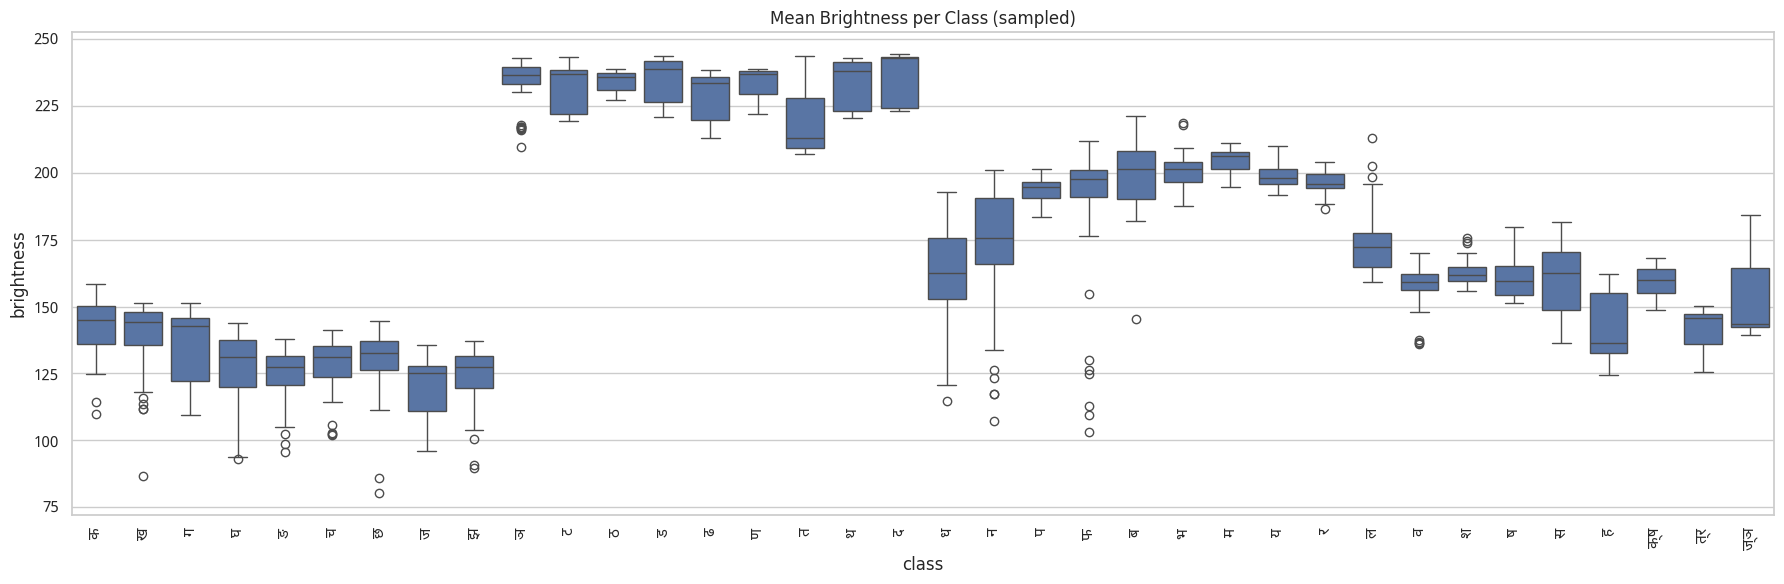

count    1500.000000
mean      178.238331
std        40.886734
min        80.431589
25%       143.367106
50%       173.438044
75%       210.618336
max       244.314800
Name: brightness, dtype: float64


In [13]:
def mean_brightness(path):
    with Image.open(path).convert("L") as img:
        return np.array(img).mean()

brightness_sample = df.sample(min(1500, len(df)), random_state=41).copy()
brightness_sample["brightness"] = brightness_sample["path"].apply(mean_brightness)

plt.figure(figsize=(18, 6))
sns.boxplot(data=brightness_sample, x="class", y="brightness", order=folders)
plt.xticks(rotation=90)
plt.title("Mean Brightness per Class (sampled)")
plt.tight_layout()
plt.show()

print(brightness_sample["brightness"].describe())

## 5. Plain vs Random background check

The raw dataset combines two source folders ("Plain Background" and "Random
Background") per class before splitting. This re-derives which images came from
which source (based on filename pattern from preprocessing) is not directly
recoverable after the UUID rename, so this section instead compares brightness/
variance as a rough proxy for background complexity - random backgrounds tend to
show higher pixel variance.

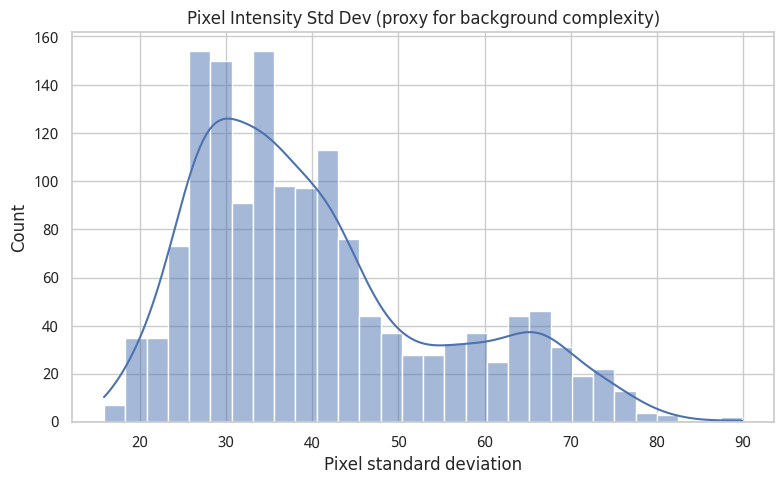

count    1500.000000
mean       40.531275
std        14.498514
min        15.804906
25%        28.894736
50%        36.489025
75%        47.851803
max        89.913410
Name: pixel_std, dtype: float64


In [14]:
def pixel_std(path):
    with Image.open(path).convert("L") as img:
        return np.array(img).std()

variance_sample = df.sample(min(1500, len(df)), random_state=41).copy()
variance_sample["pixel_std"] = variance_sample["path"].apply(pixel_std)

plt.figure(figsize=(8, 5))
sns.histplot(variance_sample["pixel_std"], bins=30, kde=True)
plt.title("Pixel Intensity Std Dev (proxy for background complexity)")
plt.xlabel("Pixel standard deviation")
plt.tight_layout()
plt.show()

print(variance_sample["pixel_std"].describe())

## 6. Corrupt / unreadable file scan

In [15]:
from PIL import UnidentifiedImageError

bad_files = []

for p in df["path"]:
    try:
        with Image.open(p) as img:
            img.verify()
    except (UnidentifiedImageError, OSError) as e:
        bad_files.append((p, str(e)))

print(f"Checked {len(df)} files.")
print(f"Corrupt/unreadable files found: {len(bad_files)}")

if bad_files:
    for p, err in bad_files[:20]:
        print(p, "->", err)

Checked 54000 files.
Corrupt/unreadable files found: 0


## 7. Summary

Quick recap of what this notebook found - fill in after running, so the whole
group has one shared reference instead of re-deriving these numbers separately.

In [16]:
print("Total images:", len(df))
print("Classes:", df["class"].nunique())
print("\nSplit sizes:")
print(split_counts)
print("\nClass count range:", total_per_class.min(), "-", total_per_class.max())
print("Corrupt files:", len(bad_files))

Total images: 54000
Classes: 36

Split sizes:
split
train    35100
val      10800
test      8100
Name: count, dtype: int64

Class count range: 1500 - 1500
Corrupt files: 0
